Environment Preparation:
Install mindspore
<br>
May need to perform a full clean installation by clearing all the cache memory
<br>
Colab may update their package silently and causing error in next running. What can you do?
Use this: !pip install numpy==1.26.4 protobuf==4.25.6 mindspore==2.5.0 --quiet <br>
If colab still forces update then use this:
!pip install numpy==1.26.4 protobuf==4.25.6 mindspore==2.5.0 --force-reinstall --ignore-installed --quiet

In [ ]:
#Nuclear Option: Full Clean Reinstall
# STEP 1: Clean install
!pip uninstall -y mindspore numpy protobuf --break-system-packages
!pip cache purge
!pip install numpy==1.26.4 protobuf==4.25.6 --force-reinstall --break-system-packages
!pip install mindspore==2.5.0 --force-reinstall --break-system-packages

Found existing installation: mindspore 2.5.0
Uninstalling mindspore-2.5.0:
  Successfully uninstalled mindspore-2.5.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
Found existing installation: protobuf 5.29.4
Uninstalling protobuf-5.29.4:
  Successfully uninstalled protobuf-5.29.4
Files removed: 28
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 56.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 17.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
grpcio-status 1.71.0 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 4.25.6 which is incompatible.
  Using cached numpy-1.26.4-cp311-cp311-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
     ━━━━━

In [ ]:
# STEP 3: Verify
import numpy as np
from mindspore import Tensor, ops, context

In [ ]:
#run this statement to check the version
import numpy, mindspore
print("NumPy:", numpy.__version__)       # Should be 1.26.4
print("MindSpore:", mindspore.__version__)  # Should be 2.5.0

NumPy: 1.26.4
MindSpore: 2.5.0


In [ ]:
import numpy as np
from mindspore import Tensor
from mindspore import dtype

#use an array to create a tensor
x = Tensor(np.array([[1,2],[3,4]]), dtype.int32)
x

Tensor(shape=[2, 2], dtype=Int32, value=
[[1, 2],
 [3, 4]])

In [ ]:
#use a number to create tensors
y=Tensor(1.0, dtype.int32)
z=Tensor(2, dtype.int32)
y
z

Tensor(shape=[], dtype=Int32, value= 2)

In [ ]:
#inherit attributes of another tensor to form a new tensor
from mindspore import ops
oneslike=ops.OnesLike()
x = Tensor(np.array([[0,1],[2,1]]).astype(np.int32))
output=oneslike(x)
output

Tensor(shape=[2, 2], dtype=Int32, value=
[[1, 1],
 [1, 1]])

In [ ]:
#output constant tensor value
from mindspore.ops import operations as ops

shape=(2,2)
ones=ops.Ones()
output=ones(shape,dtype.float32)
print(output)

zeros=ops.Zeros()
output=zeros(shape, dtype.float32)
print(output)

[[1. 1.]
 [1. 1.]]
[[0. 0.]
 [0. 0.]]


In [ ]:
from mindspore import context
context.set_context(mode=context.GRAPH_MODE, device_target="CPU")


[WARNING] ME(11054:134134735056896,MainProcess):2025-03-27-08:56:35.214.000 [mindspore/context.py:1335] For 'context.set_context', the parameter 'device_target' will be deprecated and removed in a future version. Please use the api mindspore.set_device() instead.


In [ ]:
'''
generating datasets (both train and test through get_data)
assume the cost function to be fitted is f(x)=2x+3.
f(x)=2x+3+noise is used to generate data (noise is a random value that comply
with standard normal distribution)
'''
import numpy as np

def get_data(num, w=2.0, b=3.0):
    for _ in range(num):
        x = np.random.uniform(-10.0, 10.0)
        noise = np.random.normal(0, 1)
        y = x * w + b + noise
        yield np.array([x]).astype(np.float32), np.array([y]).astype(np.float32)

In [ ]:
import matplotlib.pyplot as plt

eval_data = list(get_data(50))
x_target_label = np.array([-10, 10, 0.1])
y_target_label = x_target_label * 2 + 3
x_eval_label,y_eval_label = zip(*eval_data)



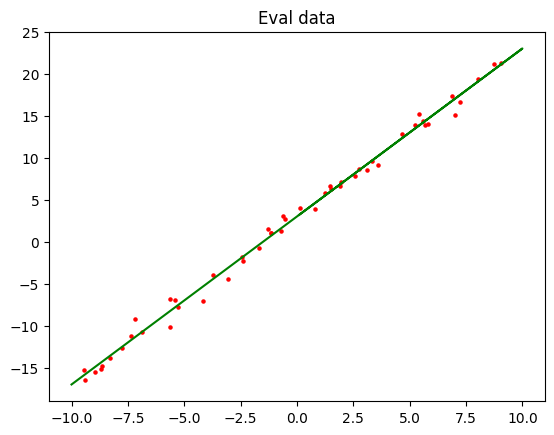

In [ ]:
plt.scatter(x_eval_label, y_eval_label, color="red", s=5)
plt.plot(x_target_label, y_target_label, color="green")
plt.title("Eval data")
plt.show()

In [ ]:
from mindspore import dataset as ds

def create_dataset(num_data, batch_size=16, repeat_size=1):
    input_data = ds.GeneratorDataset(list(get_data(num_data)), column_names=['data','label'])
    input_data = input_data.batch(batch_size)
    input_data = input_data.repeat(repeat_size)
    return input_data

In [ ]:
data_number = 1600
batch_number = 16
repeat_number = 1

ds_train = create_dataset(data_number, batch_size=batch_number, repeat_size=repeat_number)
print("The dataset size of ds_train:", ds_train.get_dataset_size())
dict_datasets = next(ds_train.create_dict_iterator())

print(dict_datasets.keys())
print("The x label value shape:", dict_datasets["data"].shape)
print("The y label value shape:", dict_datasets["label"].shape)

The dataset size of ds_train: 100
dict_keys(['data', 'label'])
The x label value shape: (16, 1)
The y label value shape: (16, 1)


In MindSpore, use nn.Dense to generate a linear function model of single data input and single data output. Thus, the function model is f(x) = wx + b
<br>use the normal operator to randomly initialize the weights w and b

In [ ]:
from mindspore.common.initializer import Normal
from mindspore import nn

class LinearNet(nn.Cell):
    def __init__(self):
        super(LinearNet, self).__init__()
        self.fc = nn.Dense(1, 1, Normal(0.02), Normal(0.02))

    def construct(self, x):
        x = self.fc(x)
        return x

In [ ]:
#Call the network to view the initialized model parameters.
net = LinearNet()
model_params = net.trainable_params()
for param in model_params:
    print(param, param.asnumpy())

Parameter (name=fc.weight, shape=(1, 1), dtype=Float32, requires_grad=True) [[0.02804621]]
Parameter (name=fc.bias, shape=(1,), dtype=Float32, requires_grad=True) [0.00609335]


In [ ]:
'''
After initializing the network model, visualize the initialized network
function and training dataset to understand the model function
before fitting.
'''
from mindspore import Tensor

x_model_label = np.array([-10, 10, 0.1])
y_model_label = (x_model_label * Tensor(model_params[0]).asnumpy()[0][0] +
                 Tensor(model_params[1]).asnumpy()[0])


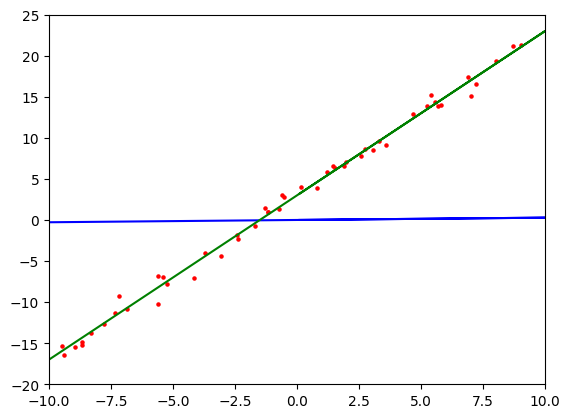

In [ ]:
plt.axis([-10, 10, -20, 25])
#define the range of x (from -10 to 10) and y axis (from -20 to 25)
plt.scatter(x_eval_label, y_eval_label, color="red", s=5)
plt.plot(x_model_label, y_model_label, color="blue")
plt.plot(x_target_label, y_target_label, color="green")
plt.show()